In [1]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from utils_analysis_old import *
import numpy as np
import seaborn as sb
from collections import Counter

In [2]:
prefix = "/home/infres/rapaport/results/FULL/focus/classes"
class_files = os.listdir(prefix)
alone, single, couple, triple = Counter(), Counter(), Counter(), Counter()
df = pd.DataFrame()
for file in class_files:
    df = pd.concat([df, pd.read_csv(prefix + "/" + file, delimiter=";")])
    #df = pd.read_csv(file, delimiter=";")
stats = list(map(lambda categ: categ.strip("{}").split(", "), df["sub_categories"]))
out_of = add_relations_v2(alone, single, couple, triple, stats)

In [3]:
df_non_git = df.loc[(df['origin'].apply(lambda x: not re.search("git", x))), ['origin', 'branch_name']]

In [4]:
pd.set_option('display.max_colwidth', None) 
pattern = r"^refs/heads/(main|master|dev|devel|develop|development)$"
df_filtered = df_non_git.loc[df_non_git['branch_name'].apply(lambda x: re.search(pattern, x) is not None), ['origin', 'branch_name']]
print(df_filtered.to_string(index=False))

                                                       origin       branch_name
                    https://sissource.ethz.ch/sispub/openbis/ refs/heads/master
      https://forgemia.inra.fr/lbe/opensilexlbe/opensilex-dev refs/heads/master
                            https://dart.googlesource.com/sdk    refs/heads/dev
      https://forgemia.inra.fr/lbe/opensilexlbe/opensilex-dev refs/heads/master
      https://forgemia.inra.fr/lbe/opensilexlbe/opensilex-dev refs/heads/master
                            https://dart.googlesource.com/sdk    refs/heads/dev
      https://forgemia.inra.fr/lbe/opensilexlbe/opensilex-dev refs/heads/master
https://forgemia.inra.fr/umr-astre/training/evolution-rscript refs/heads/master
      https://forgemia.inra.fr/lbe/opensilexlbe/opensilex-dev refs/heads/master
                    https://debugvisualisation.googlecode.com refs/heads/master
                      https://notabug.org/libreboot/libreboot refs/heads/master


In [5]:
size = len(df)
meta_size = len(df.loc[df['main_category'] == 'META'])
print("nb META: ", meta_size)
dir_size = len(df.loc[df['main_category'] == 'DIR'])
print("nb DIR: ", dir_size)
smt = size - meta_size - dir_size
smt2 = df.loc[(df['main_category'] != 'META') & (df['main_category'] != 'DIR')]
smt2

nb META:  144519
nb DIR:  565352


,origin,snapshot_src,branch_name,missing_commit,snapshot_dst,first_difference,main_category,sub_categories
7660,https://github.com/Daiver/jff,swh:1:snp:79e45326b8bff8f2a5f5851e21143629cdc3a08b,refs/heads/master,swh:1:rev:43634fc0eb5e4df125328b096325fa6a3b698f37,swh:1:snp:f0d11befc08f065f388df195854a2c9245d3349d,NaN,LoadingIssue,{}
11128,https://github.com/blerou/dotfiles,swh:1:snp:c2874015dbd8fd49880b000cf14367b8791a12e5,refs/heads/master,swh:1:rev:e066f803e2a6f38f34b07770038e19c5273c51d5,swh:1:snp:7fecf392a98c486b6ec3c8bad2ed336ac0f9b4a7,NaN,LoadingIssue,{}
12693,https://github.com/kbhomes/kbhomes.github.com,swh:1:snp:a6ae8d0c85cf5c22c5a296ca2112a4ddbf6d0780,refs/heads/master,swh:1:rev:391805e6fd6cc7478176bcf7c1259e6bd9dd148a,swh:1:snp:d481f79fecd37a5e8213786566126edc556a7ea9,NaN,LoadingIssue,{}
4059,https://github.com/neilguangzhou/neilguangzhou.github.io,swh:1:snp:6878996706c517ffa354158332158474006b6e70,refs/heads/master,swh:1:rev:784ef55c03d4d9feac865159704565e92f8804dd,swh:1:snp:4fcad53008b30f1349f56341c109d69e90493bab,NaN,LoadingIssue,{}
7135,https://github.com/tfrere/frameworkCss,swh:1:snp:b4e7f017abea8d55c9514668529cc3a657ad2f33,refs/heads/master,swh:1:rev:1ef43d77cad9f835c087c8c2cddf131c4458e05e,swh:1:snp:ffa60fbdabe77ea166827833849c9e5ca981f527,NaN,LoadingIssue,{}
1005,https://github.com/cf020031308/cf020031308.github.io,swh:1:snp:53543c96aed7d7a52f19fe7bce43ee3c0270ee66,refs/heads/master,swh:1:rev:3e77c4df1b1af75a61dcacfa126dd74ccd33ae5a,swh:1:snp:da1eefde0ee127fb3e16021c91cf70c6b4878761,NaN,LoadingIssue,{}
2968,https://github.com/HeroWit/HeroWit.github.io,swh:1:snp:8393acb4dea530619266631d4c07306293183d1c,refs/heads/master,swh:1:rev:61cd15f16fd4fc787df35b3c51b0d66d8fa73a5b,swh:1:snp:60416816d0b7b75f8335f70344efc0bec4a1a051,NaN,LoadingIssue,{}


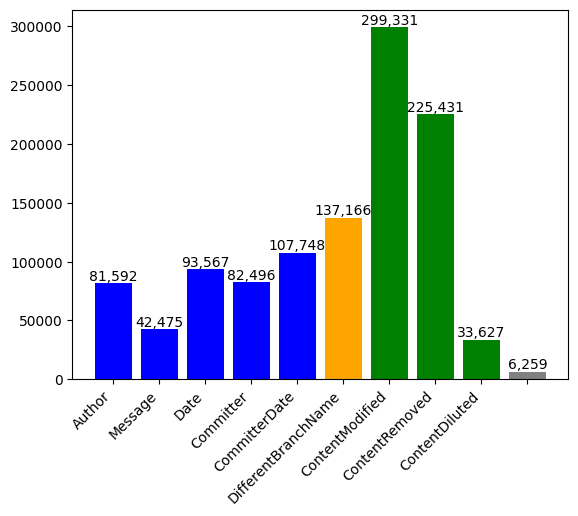

Counter({'ContentModified': 299331,
         'ContentRemoved': 225431,
         'DifferentBranchName': 137166,
         'CommitterDate': 107748,
         'Date': 93567,
         'Committer': 82496,
         'Author': 81592,
         'Message': 42475,
         'ContentDiluted': 33627,
         '': 6259})

In [6]:
display_single(single)
single

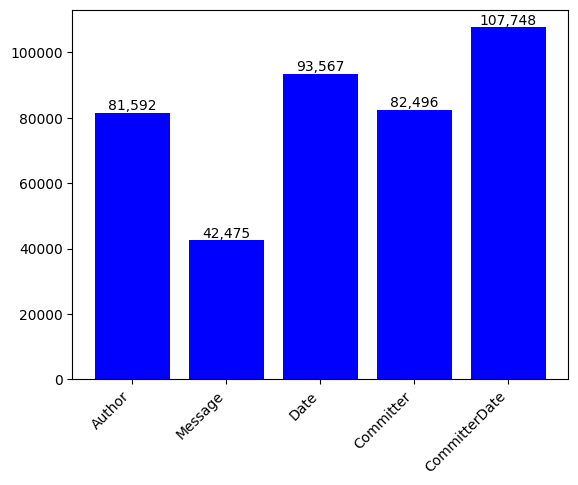

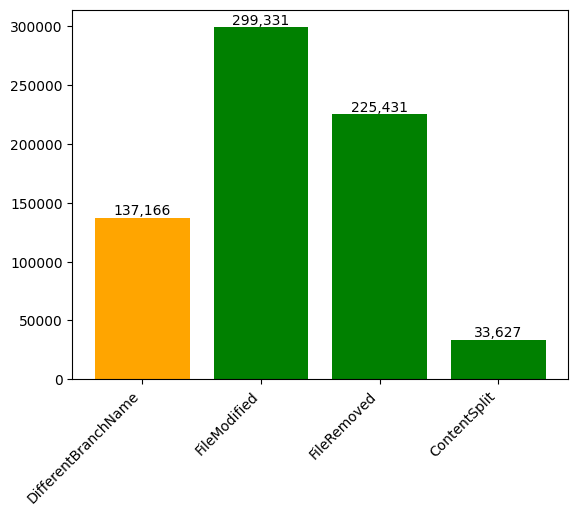

In [7]:
display_single_META(single)
display_single_DIR(single)

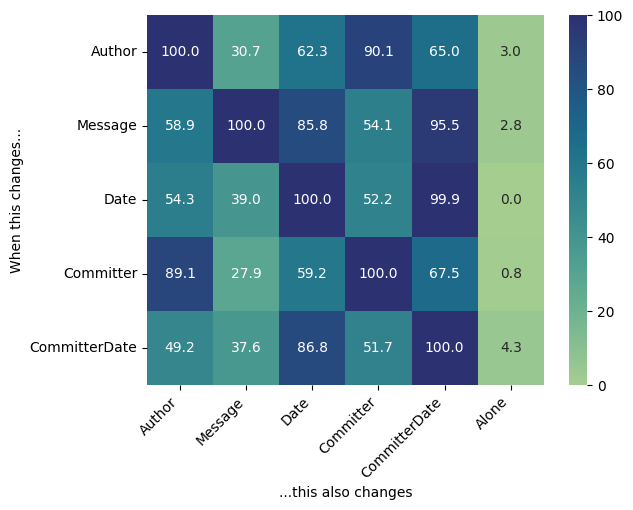

[np.float64(58.57772247947022),
 np.float64(39.187049049445626),
 np.float64(65.67476825370703),
 np.float64(58.00195281686002),
 np.float64(71.30780006930188),
 np.float64(1.8268476974138508)]

In [8]:
hc = heatmap_couple(couple, alone, single, True)
means = [0]*6
for x in range(len(hc)):
    for y in range(len(hc[x])):
        means[y] += hc[x][y]
[x/6 for x in means]

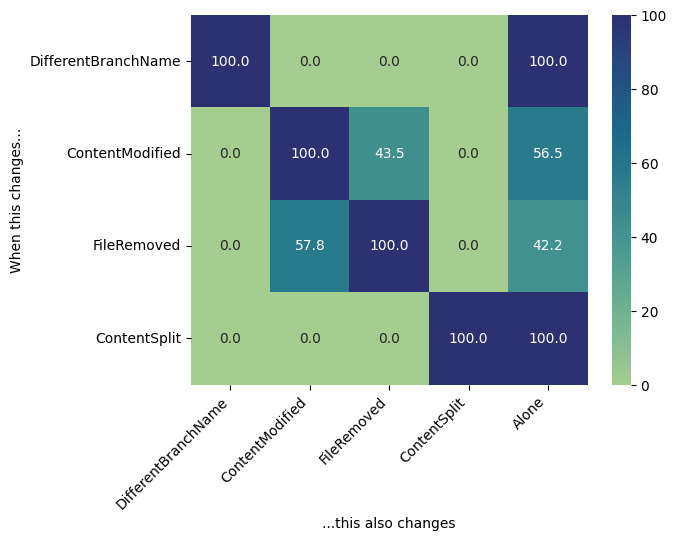

[np.float64(20.0),
 np.float64(31.55147251265354),
 np.float64(28.699600108241377),
 np.float64(20.0),
 np.float64(59.74892737910509)]

In [9]:
hc = heatmap_couple_dir(couple, alone, single, True)
means = [0]*5
for x in range(len(hc)):
    for y in range(len(hc[x])):
        means[y] += hc[x][y]
[x/5 for x in means]

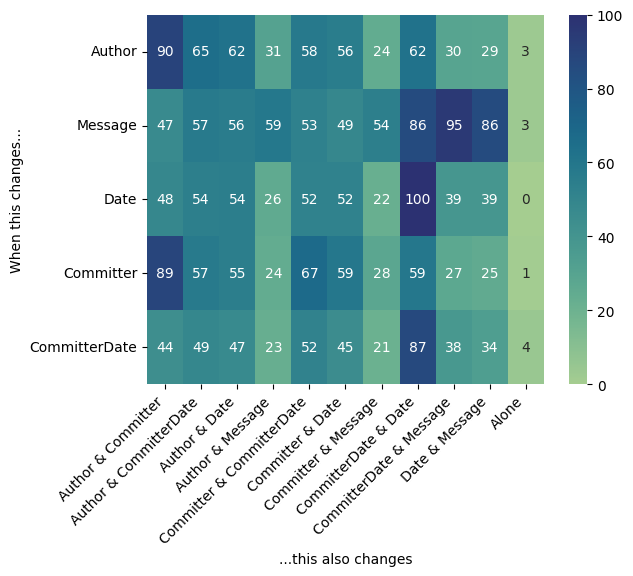

In [10]:
ht = heatmap_triple(triple, couple, single, alone, True)

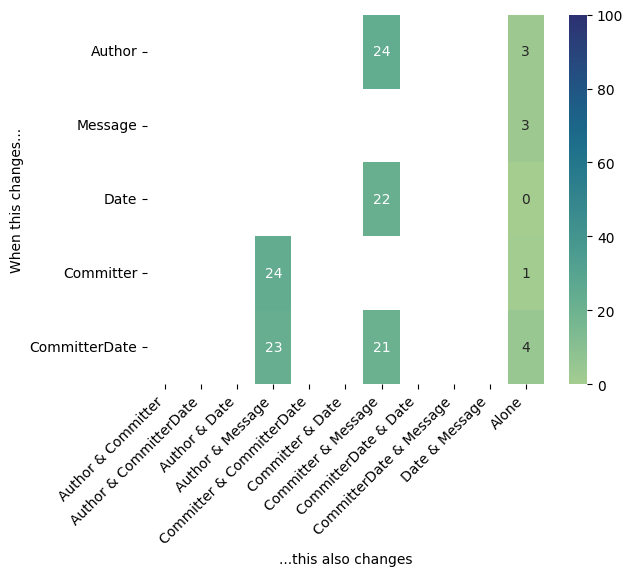

In [11]:
ht = heatmap_triple(triple, couple, single, alone, display=False)
display_triple(ht, filter_percent(ht, 0, 25), with_mask_couple=False)

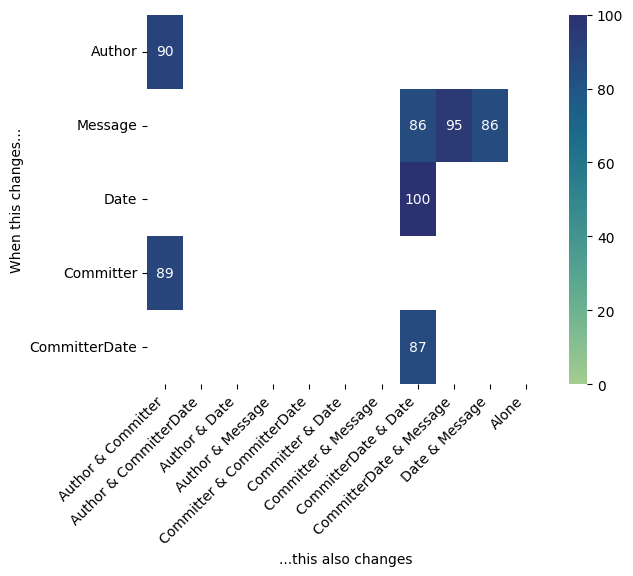

In [14]:
ht = heatmap_triple(triple, couple, single, alone, display=False)
display_triple(ht, filter_percent(ht, 75, 100), with_mask_couple=False)